In [1]:
import siibra
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import plotly.graph_objects as go
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

[siibra:INFO] Version: 1.0.1-alpha.10
[siibra:WARNING] This is a development release. Use at your own risk.
[siibra:INFO] Please file bugs and issues at https://github.com/FZJ-INM1-BDA/siibra-python.


# Sphere

In [2]:
#class to implement sphere as was in original Fleming paper
class Sphere_random_point_generator():
    def __init__(self, radius, encapsulation_radius, stimulating_electrode_position):
        self.radius = radius
        self.encapsulation_radius = encapsulation_radius
        self.stimulating_electrode_position = stimulating_electrode_position

    def generate_positions(self, n):
        """Return `n` points distributed randomly with uniform density within the sphere with encapsulation layer"""
        num_points = n

        x_points = []
        y_points = []
        z_points = []

        # Sample angles - https://mathworld.wolfram.com/SpherePointPicking.html
        theta = 2*np.pi*np.random.uniform(0, 1, num_points)
        phi = np.arccos(2*np.random.uniform(0, 1, num_points)-1)

        # Sample radius
        r = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))

        # Convert to Cartesian
        x_points = r*np.sin(phi)*np.cos(theta)
        y_points = r*np.sin(phi)*np.sin(theta)
        z_points = r*np.cos(phi) + self.stimulating_electrode_position[2]

        invalid_points = (x_points**2 + y_points**2 < self.encapsulation_radius**2)

        while np.any(invalid_points):
            n = invalid_points.sum()

            theta = 2*np.pi*np.random.uniform(0, 1, n)
            phi = np.arccos(2*np.random.uniform(0, 1, n)-1)
            r = self.radius * np.cbrt(np.random.uniform(0, 1, n))

            x_points[invalid_points] = r*np.sin(phi)*np.cos(theta)
            y_points[invalid_points] = r*np.sin(phi)*np.sin(theta)
            z_points[invalid_points] = r*np.cos(phi) + self.stimulating_electrode_position[2]

            invalid_points = (x_points**2 + y_points**2) < self.encapsulation_radius**2

        points = np.column_stack((x_points, y_points, z_points))
        return points


In [21]:
random_point_generator = Sphere_random_point_generator(2000, 1135, np.array([0, 0, 0]))
positions = random_point_generator.generate_positions(1000)

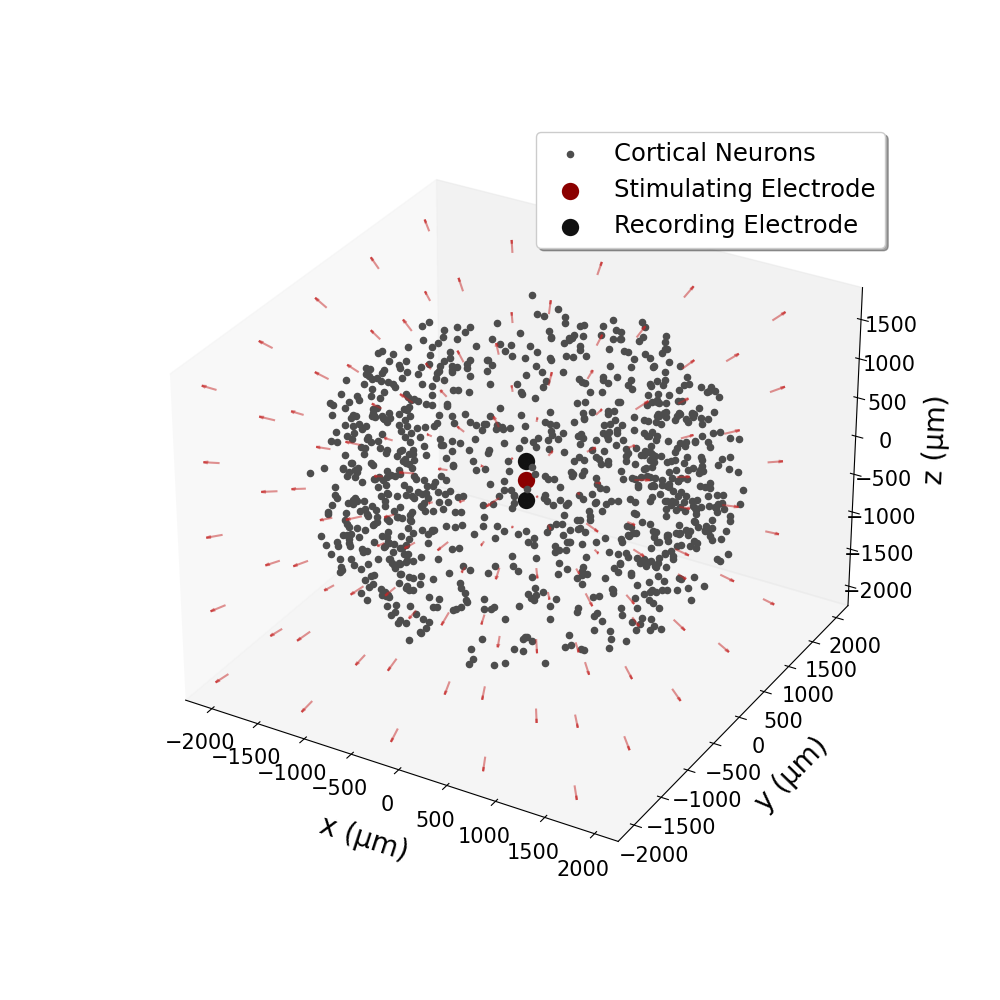

In [22]:
%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('x (μm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('z (μm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('y (μm)', fontsize = 20, labelpad = 15)


##### add in the cortical neurons##############
x_points = positions[:,0]
y_points = positions[:,1]
z_points = positions[:,2]

ax.scatter(x_points, y_points, z_points, c='#4D4D4D', label = "Cortical Neurons", depthshade=False)
ax.scatter(np.array([0]), np.array([0]), np.array([0]), c='#8B0000', label = "Stimulating Electrode", linewidth=8)
ax.scatter(np.array([0,0]), np.array([0,0]), np.array([-250,250]), color='#111111', depthshade=False, label = "Recording Electrode", linewidth=8)

legend = ax.legend(loc='upper right', shadow=True, fontsize=17.5)



ax.grid(False)

ax.tick_params(axis='both', which='major', labelsize=15, pad = 5)



############# add in the e field lines ##################
# Create 3D grid
x = np.linspace(-2000, 2500, 100)
y = np.linspace(-2000, 2500, 100)
z = np.linspace(-2000, 2500, 100)
X, Y, Z = np.meshgrid(x, y, z)

# Radial distance
r = np.sqrt(X**2 + Y**2 + Z**2)
r[r == 0] = 1e-9

# Electric field (normalized for visualization)
Ex = X / r
Ey = Y / r
Ez = Z / r

# Normalize vectors for clean arrows
norm = np.sqrt(Ex**2 + Ey**2 + Ez**2)
norm[norm == 0] = 1e-12 
Exn = Ex / norm
Eyn = Ey / norm
Ezn = Ez / norm

# Sparse vector field
step = 20
ax.quiver(
    X[::step, ::step, ::step],
    Y[::step, ::step, ::step],
    Z[::step, ::step, ::step],
    Exn[::step, ::step, ::step],
    Eyn[::step, ::step, ::step],
    Ezn[::step, ::step, ::step],
    length=150,
    color='#C62828',
    alpha = 0.5
)

plt.show()
#### uncomment this for top down view #####
ax.view_init(elev=90, azim=-90)
ax.zaxis.set_label_position('none')
ax.zaxis.set_ticks_position('none')
###########################################
plt.savefig("sphere_with_point_source_top_down.svg", format="svg")

# Ellipse

In [2]:
#class to implement elliptical shape
class Ellipsoid_random_point_generator():
    """
    Represents a ellipitical volume within which neurons may be distributed.
    """
    def __init__(self, radius_x, radius_y, radius_z, encapsulation_radius, stimulating_electrode_position, rotation_angle):
        self.radius_x = radius_x
        self.radius_y = radius_y
        self.radius_z = radius_z
        self.encapsulation_radius = encapsulation_radius
        self.stimulating_electrode_position = stimulating_electrode_position
        self.rotation_angle = rotation_angle

    def generate_positions(self, n):
        """Return `n` points distributed randomly with uniform density within the eclipse"""
        num_points = n

        #rotation angle of an ellipse defines its tilt relative to the standard x-axis
        self.rotation_angle = np.pi/2 - self.rotation_angle

        x_points = []
        y_points = []
        z_points = []


        # Generate a random point inside the sphere
        theta = 2*np.pi*np.random.uniform(0, 1, num_points)
        phi = np.arccos(2*np.random.uniform(0, 1, num_points)-1)
        x_radius = self.radius_x*np.cbrt(np.random.uniform(0, 1, num_points))
        y_radius = self.radius_y*np.cbrt(np.random.uniform(0, 1, num_points))
        z_radius = self.radius_z*np.cbrt(np.random.uniform(0, 1, num_points))

        x = x_radius * np.sin(phi) * np.cos(theta)
        y = y_radius * np.sin(phi) * np.sin(theta)
        z = z_radius * np.cos(phi)+ self.stimulating_electrode_position[2]

        invalid = (x**2 + y**2 < self.encapsulation_radius**2) 

        while np.any(invalid):
            n = invalid.sum()
            # Generate a random point inside the sphere
            theta = 2*np.pi*np.random.uniform(0, 1, n)
            phi = np.arccos(2*np.random.uniform(0, 1, n)-1)
            x_radius = self.radius_x*np.cbrt(np.random.uniform(0, 1, n))
            y_radius = self.radius_y*np.cbrt(np.random.uniform(0, 1, n))
            z_radius = self.radius_z*np.cbrt(np.random.uniform(0, 1, n))

            x[invalid] = x_radius * np.sin(phi) * np.cos(theta)
            y[invalid] = y_radius * np.sin(phi) * np.sin(theta)
            z[invalid] = z_radius * np.cos(phi)+ self.stimulating_electrode_position[2]

            invalid = (x**2 + y**2 < self.encapsulation_radius**2)

        #rotate around the z axis
        x_points = x*np.cos(self.rotation_angle) - y*np.sin(self.rotation_angle)
        y_points = y*np.cos(self.rotation_angle) + x*np.sin(self.rotation_angle)
        z_points = z
        
        points = np.column_stack((x_points, y_points, z_points))
        return points


In [3]:
random_point_generator = Ellipsoid_random_point_generator(4176,3080,2961, 1135, np.array([0, 0, 0]), 0.610865)
positions = random_point_generator.generate_positions(1000)

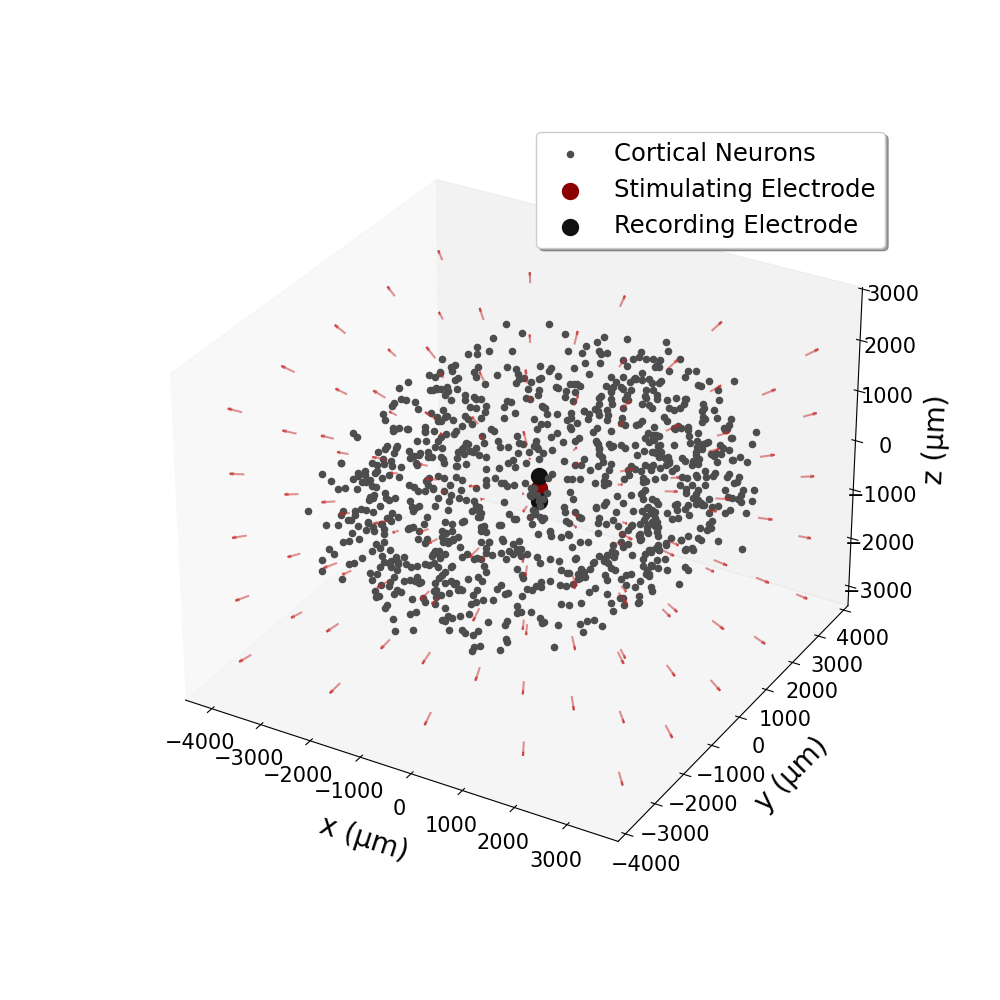

In [4]:
%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('x (μm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('z (μm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('y (μm)', fontsize = 20, labelpad = 15)


##### add in the cortical neurons##############
x_points = positions[:,0]
y_points = positions[:,1]
z_points = positions[:,2]

ax.scatter(x_points, y_points, z_points, c='#4D4D4D', label = "Cortical Neurons", depthshade=False)
ax.scatter(np.array([0]), np.array([0]), np.array([0]), c='#8B0000', label = "Stimulating Electrode", linewidth=8)
ax.scatter(np.array([0,0]), np.array([0,0]), np.array([-250,250]), color='#111111', depthshade=False, label = "Recording Electrode", linewidth=8)

legend = ax.legend(loc='upper right', shadow=True, fontsize=17.5)
ax.grid(False)

ax.tick_params(axis='both', which='major', labelsize=15, pad = 5)

############# add in the e field lines ##################
# Create 3D grid
x = np.linspace(-4000, 5000, 100)
y = np.linspace(-3000, 5000, 100)
z = np.linspace(-3000, 3000, 100)
X, Y, Z = np.meshgrid(x, y, z)

# Radial distance
r = np.sqrt(X**2 + Y**2 + Z**2)
r[r == 0] = 1e-9

# Electric field (normalized for visualization)
Ex = X / r
Ey = Y / r
Ez = Z / r

# Normalize vectors for clean arrows
norm = np.sqrt(Ex**2 + Ey**2 + Ez**2)
norm[norm == 0] = 1e-12 
Exn = Ex / norm
Eyn = Ey / norm
Ezn = Ez / norm

# Sparse vector field
step = 20
ax.quiver(
    X[::step, ::step, ::step],
    Y[::step, ::step, ::step],
    Z[::step, ::step, ::step],
    Exn[::step, ::step, ::step],
    Eyn[::step, ::step, ::step],
    Ezn[::step, ::step, ::step],
    length=250,
    color='#C62828',
    alpha = 0.5
)

plt.show()
#### uncomment this for top down view #####
ax.view_init(elev=90, azim=-90)
ax.zaxis.set_label_position('none')
ax.zaxis.set_ticks_position('none')
###########################################
plt.savefig("ellipsoid_with_point_source_top_down.svg", format="svg")

# Julich

In [5]:
class Julich_brain_cyto_random_point_generator:
    def __init__(self,parcellation, region, space, stimulating_electrode_position, encapsulation_radius):
        #obtain the brain region required
        self.region = siibra.get_region(parcellation, region)

        #get the space required
        self.space = self.region.spaces.get(space)


        self.region_map = self.region.get_regional_map(space, maptype="statistical")
        self.NIfTI_region = self.region_map.fetch()
        self.region_data = self.NIfTI_region.get_fdata()
        self.affine = self.NIfTI_region.affine

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)

        #stimulating electrode position and encapsulation
        self.stimulating_electrode_position = stimulating_electrode_position
        self.encapsulation_radius = encapsulation_radius


    def generate_positions(self, number_points):
        indices = np.random.choice(len(self.region_data_indices), size = number_points)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.4, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_coordinates = world_points[:, 0] - self.stimulating_electrode_position[0]
        y_coordinates = world_points[:, 1] - self.stimulating_electrode_position[1]


        mask = ~(x_coordinates**2 + y_coordinates**2 < self.encapsulation_radius**2)

        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]


        return world_points


In [6]:
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1"
region = "STN (Subthalamus) right"
coordinate_space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
electrode_position_mm = np.array([12000,-12000,-8500])/1000
encapsulation_mm = 1135/1000

random_point_generator = Julich_brain_cyto_random_point_generator(parcellation,region,coordinate_space, electrode_position_mm, encapsulation_mm)
STN_space = random_point_generator.generate_positions(1000)


Loading preconfigured Map instances: 100%|████████████████████████████████████████████| 59/59 [00:00<00:00, 124.05Map/s]
[siibra:WARNING] Map registry contains multiple classes: SparseMap, Map


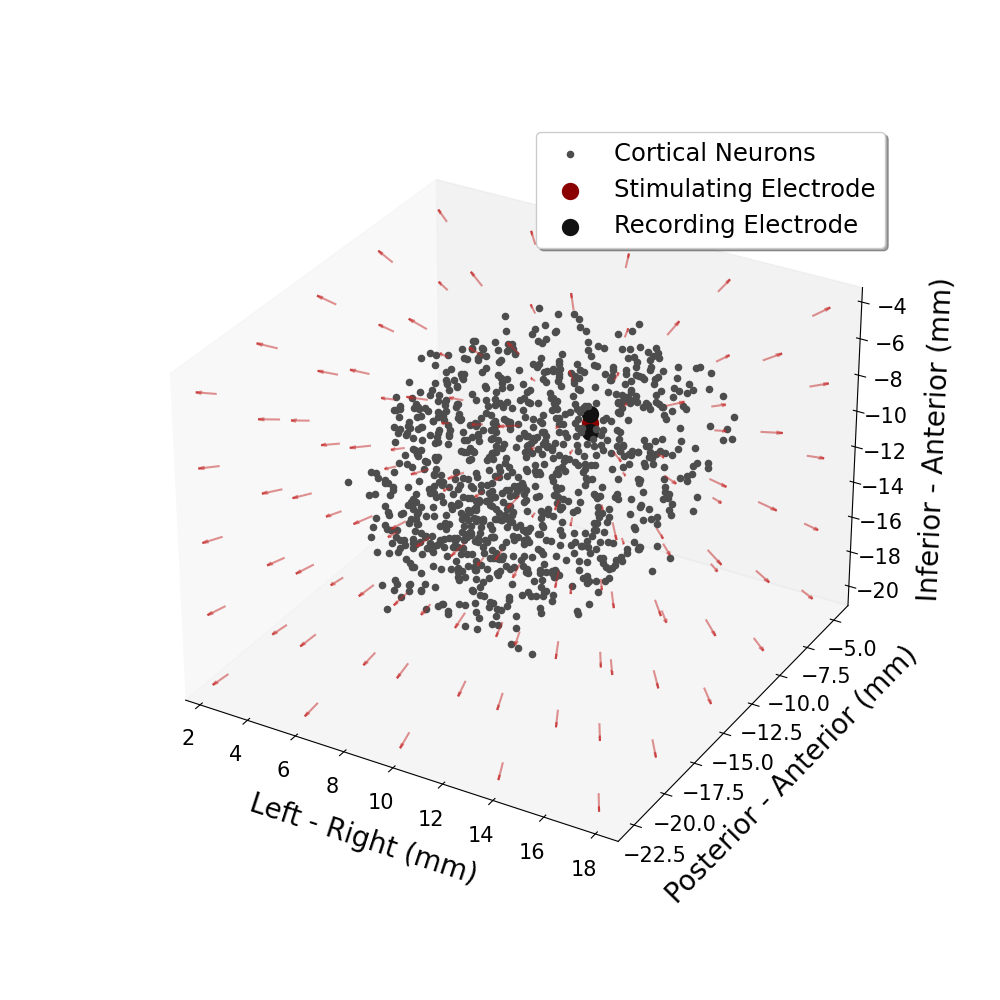

In [7]:
%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Left - Right (mm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('Inferior - Anterior (mm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('Posterior - Anterior (mm)', fontsize = 20, labelpad = 15)


##### add in the cortical neurons##############
x_points = STN_space[:,0]
y_points = STN_space[:,1]
z_points = STN_space[:,2]

ax.scatter(x_points, y_points, z_points, c='#4D4D4D', label = "Cortical Neurons",depthshade=False)
ax.scatter(np.array([12]), np.array([-12]), np.array([-8.5]), c='#8B0000', label = "Stimulating Electrode", linewidth=8)
ax.scatter(np.array([12,12]), np.array([-12,-12]), np.array([-8,-9]), color='#111111', depthshade=False, label = "Recording Electrode", linewidth=8)


#############efield
x0, y0, z0 = 12, -12, -8.5 

x = np.linspace(2.5, 20, 15)
y = np.linspace(-22.5, -2, 15)
z = np.linspace(-20, -2, 15)

X, Y, Z = np.meshgrid(x, y, z)

# -------------------------
# Shift coordinates
# -------------------------
Rx = X - x0
Ry = Y - y0
Rz = Z - z0

r = np.sqrt(Rx**2 + Ry**2 + Rz**2)

# Avoid singularity
mask = r > 0.5

# Electric field (no constants for visualization)
Ex = np.zeros_like(Rx)
Ey = np.zeros_like(Ry)
Ez = np.zeros_like(Rz)

Ex[mask] = Rx[mask] / r[mask]
Ey[mask] = Ry[mask] / r[mask]
Ez[mask] = Rz[mask] / r[mask]

# -------------------------
# Normalize for clean arrows
# -------------------------
norm = np.sqrt(Ex**2 + Ey**2 + Ez**2)
norm[norm == 0] = 1

Exn = Ex / norm
Eyn = Ey / norm
Ezn = Ez / norm

# -------------------------
# Plot
# -------------------------


step = 3
ax.quiver(
    X[::step, ::step, ::step],
    Y[::step, ::step, ::step],
    Z[::step, ::step, ::step],
    Exn[::step, ::step, ::step],
    Eyn[::step, ::step, ::step],
    Ezn[::step, ::step, ::step],
    length=0.8,
    color='#C62828', 
    alpha = 0.5
)

legend = ax.legend(loc='upper right', shadow=True, fontsize=17.5)

ax.grid(False)

ax.tick_params(axis='both', which='major', labelsize=15, pad = 5)

plt.show()
#### uncomment this for top down view #####
ax.view_init(elev=90, azim=-90)
ax.zaxis.set_label_position('none')
ax.zaxis.set_ticks_position('none')
###########################################
plt.savefig("julich_with_point_source_top_down.svg", format="svg")

In [5]:
random_point_generator_sphere = Sphere_random_point_generator(2000, 1135, np.array([0, 0, 0]))
positions_sphere = random_point_generator_sphere.generate_positions(1000)

random_point_generator_ellipse = Ellipsoid_random_point_generator(4176,3080,2961, 1135, np.array([0, 0, 0]), 0.610865)
positions_ellipse = random_point_generator_ellipse.generate_positions(1000)

parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1"
region = "STN (Subthalamus) right"
coordinate_space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
electrode_position_mm = np.array([12000,-12000,-8500])/1000
encapsulation_mm = 1135/1000

random_point_generator_julich = Julich_brain_cyto_random_point_generator(parcellation,region,coordinate_space, electrode_position_mm, encapsulation_mm)
positions_julich = random_point_generator_julich.generate_positions(1000)

Loading preconfigured Map instances: 100%|████████████████████████████████████████████| 59/59 [00:00<00:00, 148.70Map/s]
[siibra:WARNING] Map registry contains multiple classes: SparseMap, Map


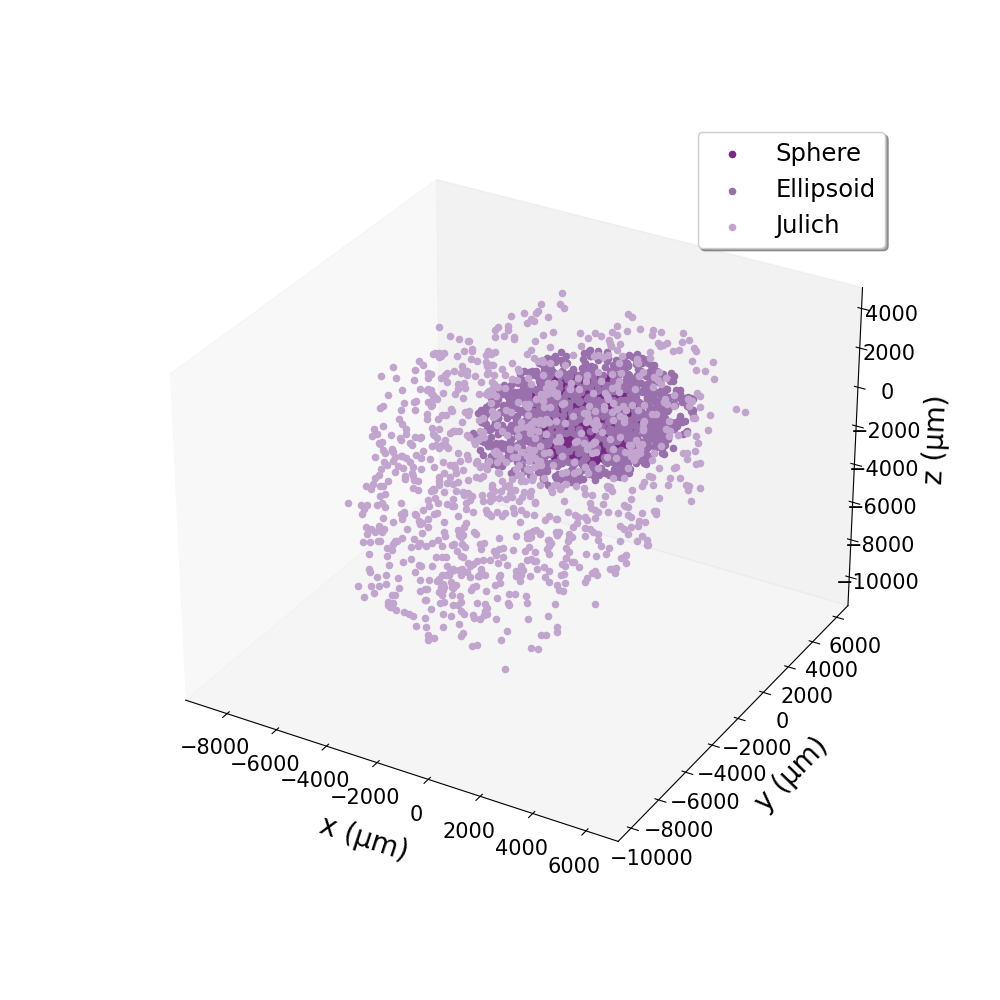

In [6]:
%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('x (μm)', fontsize = 20, labelpad = 15)
ax.set_zlabel('z (μm)', fontsize = 20, labelpad = 15)
ax.set_ylabel('y (μm)', fontsize = 20, labelpad = 15)


##### sphere##############
x_points_sphere = positions_sphere[:,0]
y_points_sphere = positions_sphere[:,1]
z_points_sphere = positions_sphere[:,2]

ax.scatter(x_points_sphere, y_points_sphere, z_points_sphere, c='#762A83', label = "Sphere", depthshade=False)

##############################################
x_points_ellipse = positions_ellipse[:,0]
y_points_ellipse = positions_ellipse[:,1]
z_points_ellipse = positions_ellipse[:,2]

ax.scatter(x_points_ellipse, y_points_ellipse, z_points_ellipse, c='#9970AB', label = "Ellipsoid", depthshade=False)

##############################################
x_points_julich = positions_julich[:,0]*1000-12000
y_points_julich = positions_julich[:,1]*1000+12000
z_points_julich = positions_julich[:,2]*1000+8500

ax.scatter(x_points_julich, y_points_julich, z_points_julich, c='#C2A5CF', label = "Julich", depthshade=False)


legend = ax.legend(loc='upper right', shadow=True, fontsize=17.5)



ax.grid(False)

ax.tick_params(axis='both', which='major', labelsize=15, pad = 5)


plt.show()
#### uncomment this for top down view #####
ax.view_init(elev=90, azim=-90)
ax.zaxis.set_label_position('none')
ax.zaxis.set_ticks_position('none')
###########################################
plt.savefig("all_spatial_positions_aligned.svg", format="svg")